<a href="https://colab.research.google.com/github/ch-fahad1/neurofive-ml-track/blob/main/Titanic_EDA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Dataset - Exploratory Data Analysis (EDA)

## NeuroFive ML Track - Week 1 Task 1

**Author:** Muhammad Fahad

### Objective

This notebook presents an exploratory data analysis (EDA) of the Titanic dataset using Python and Pandas. The objective is to understand the dataset's structure, identify missing values, analyze data types, and gain initial insights before applying machine learning techniques.

In [4]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("train.csv")

# Display first 5 rows
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [10]:
## Dataset Shape
df.shape

(891, 12)

In [11]:
## Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [12]:
## Statistical Summary
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [13]:
## Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [14]:
## Categorical and Numerical Columns

categorical_columns = df.select_dtypes(include=['object']).columns
numerical_columns = df.select_dtypes(exclude=['object']).columns

print("Categorical Columns:")
print(categorical_columns)

print("\nNumerical Columns:")
print(numerical_columns)

Categorical Columns:
Index(['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked'], dtype='object')

Numerical Columns:
Index(['PassengerId', 'Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare'], dtype='object')


## Data Story

The Titanic dataset contains records of 891 passengers with 12 features, including demographic information, ticket details, and survival status.

The dataset includes both numerical and categorical variables. During the initial exploration, I found that the **Age**, **Cabin**, and **Embarked** columns contain missing values, which will need to be handled before building any machine learning model.

This exploratory analysis provides a clear understanding of the dataset's structure and prepares it for the next step: data cleaning and visualization.


# Week 1 - Task 2

## Data Cleaning and Visualization

In this section, I clean the Titanic dataset by handling missing values and then visualize the data to better understand passenger survival patterns.


In [17]:
## Missing Values
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [18]:
# Fill missing Age values with median
df["Age"] = df["Age"].fillna(df["Age"].median())

# Fill missing Embarked values with mode
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

# Drop Cabin column because most values are missing
df.drop("Cabin", axis=1, inplace=True)

## Data Cleaning

The **Age** column contains missing values, so I filled them using the **median** because it is less affected by extreme values.

The **Embarked** column has only two missing values, so I filled them with the **mode**, which represents the most common category.

The **Cabin** column contains a large number of missing values (more than 75%), so I removed it from the dataset.

In [19]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

## Age Distribution

This histogram shows the distribution of passengers' ages.
It helps us understand which age groups were most common on the Titanic.

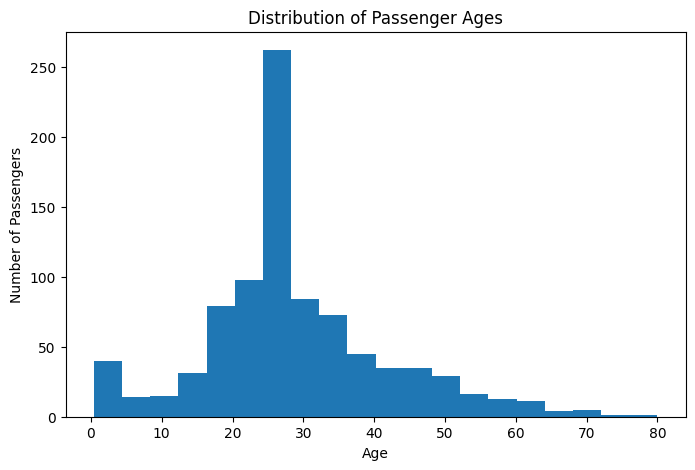

In [21]:
plt.figure(figsize=(8,5))

plt.hist(df["Age"], bins=20)

plt.title("Distribution of Passenger Ages")
plt.xlabel("Age")
plt.ylabel("Number of Passengers")

plt.show()

## Outlier Detection

A boxplot helps identify unusual values (outliers) in the Age column.

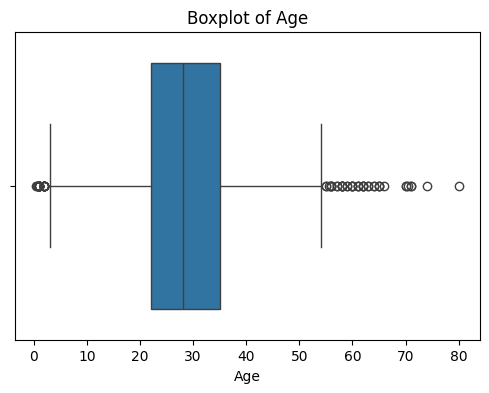

In [22]:
plt.figure(figsize=(6,4))

sns.boxplot(x=df["Age"])

plt.title("Boxplot of Age")

plt.show()

## Survival Count

This chart compares the number of passengers who survived and those who did not.

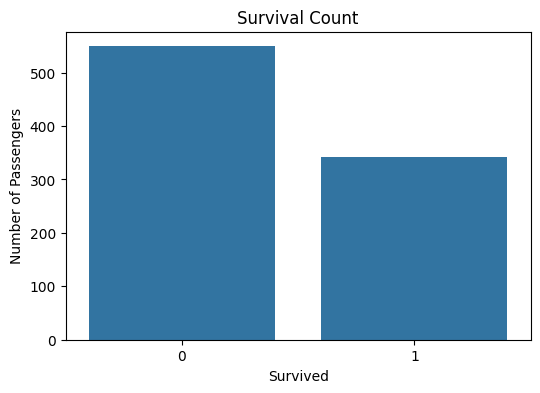

In [23]:
plt.figure(figsize=(6,4))

sns.countplot(x="Survived", data=df)

plt.title("Survival Count")

plt.xlabel("Survived")
plt.ylabel("Number of Passengers")

plt.show()

In [24]:
numeric_df = df.select_dtypes(include=["number"])

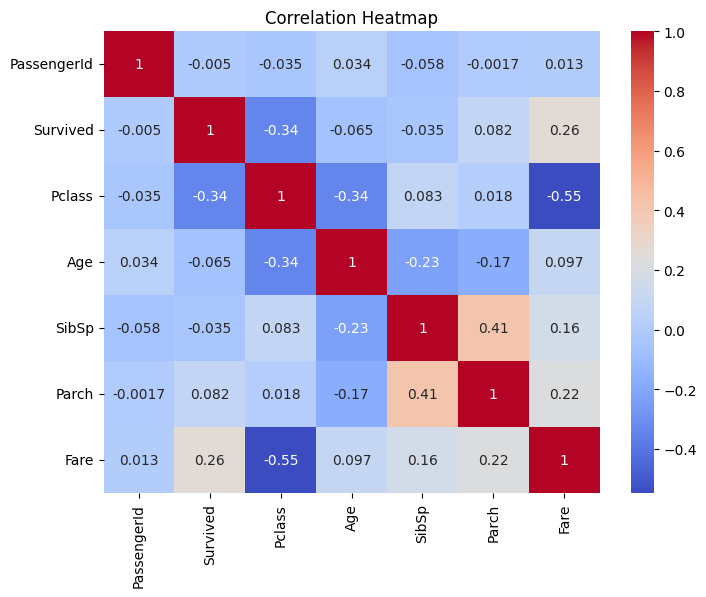

In [25]:
plt.figure(figsize=(8,6))

sns.heatmap(numeric_df.corr(), annot=True, cmap="coolwarm")

plt.title("Correlation Heatmap")

plt.show()

## Which Feature Affects Survival the Most?

I think **Passenger Class (Pclass)** has the biggest impact on survival.

The correlation heatmap shows that Pclass has the strongest relationship with the Survived column among the numerical features. Passengers traveling in first class had a higher survival rate than those in second or third class. This may be because first-class passengers had better access to lifeboats and were located on the upper decks.

## Survival by Passenger Class

This chart compares survival among different passenger classes.

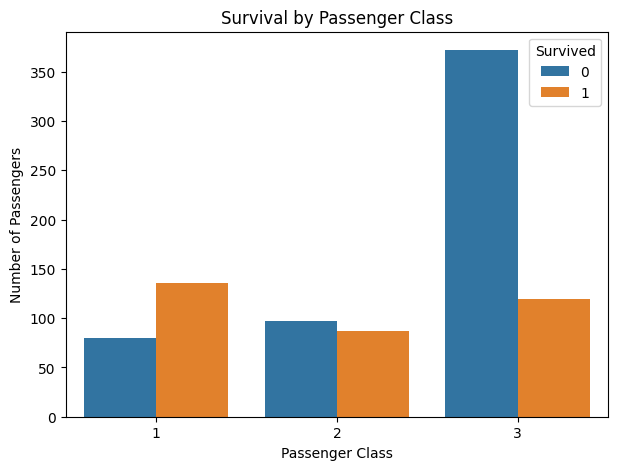

In [26]:
plt.figure(figsize=(7,5))

sns.countplot(x="Pclass", hue="Survived", data=df)

plt.title("Survival by Passenger Class")

plt.xlabel("Passenger Class")

plt.ylabel("Number of Passengers")

plt.show()

# Conclusion

In this notebook, I explored and cleaned the Titanic dataset using Pandas. I handled missing values, identified outliers, and created different visualizations to better understand the data. The analysis suggests that passenger class had the strongest impact on survival. This notebook provides a solid foundation for future machine learning tasks.